In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\train_aWnotuB.csv',
                     parse_dates=['DateTime'])

In [3]:
test  = pd.read_csv(r'C:\Users\LENOVO\Desktop\Traffic-Pattern-Forecasting\data\raw\datasets_8494_11879_test_BdBKkAj.csv',
                     parse_dates=['DateTime'])

In [4]:
train.shape

(48120, 4)

In [5]:
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

In [6]:
test.shape

(11808, 3)

In [7]:
test.columns

Index(['DateTime', 'Junction', 'ID'], dtype='str')

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[us]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 1.5 MB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  11808 non-null  datetime64[us]
 1   Junction  11808 non-null  int64         
 2   ID        11808 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 276.9 KB


In [10]:
print(train.isnull().sum())
print(test.isnull().sum())

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64
DateTime    0
Junction    0
ID          0
dtype: int64


OBSERVATION:
- There is zero null values in both train and test dataset

In [11]:
train.describe()

,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
mean,2016-09-19 06:03:56.109725,2.180549,22.791334,2.016330e+10
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10
std,NaN,0.966955,20.750063,5.944854e+06


In [12]:
def add_time_features(df):
    df = df.copy()
    df['hour']       = df['DateTime'].dt.hour
    df['dayofweek']  = df['DateTime'].dt.dayofweek      # 0=Mon … 6=Sun
    df['day']        = df['DateTime'].dt.day
    df['month']      = df['DateTime'].dt.month
    df['year']       = df['DateTime'].dt.year
    df['quarter']    = df['DateTime'].dt.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_night']   = df['hour'].isin(range(22, 24)).astype(int) | \
                       df['hour'].isin(range(0, 6)).astype(int)
    # Rush hours: 7-9 AM, 5-8 PM
    df['is_rush']    = df['hour'].isin([7,8,9,17,18,19,20]).astype(int)
    # Cyclical encoding for hour & month (avoids 23→0 discontinuity)
    df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7)
    return df
 
train = add_time_features(train)
test  = add_time_features(test)

In [13]:
train = train.sort_values(['Junction', 'DateTime']).reset_index(drop=True)
 
for lag in [1, 2, 3, 24, 168]:          # 1h, 2h, 3h, 1day, 1week
    train[f'lag_{lag}'] = train.groupby('Junction')['Vehicles'].shift(lag)
 
# Rolling stats per junction
for window in [3, 6, 24]:
    train[f'roll_mean_{window}'] = (
        train.groupby('Junction')['Vehicles']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )
    train[f'roll_std_{window}']  = (
        train.groupby('Junction')['Vehicles']
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

In [14]:
train_clean = train.dropna().reset_index(drop=True)
print(f"\nRows after lag dropna: {len(train_clean)} (dropped {len(train)-len(train_clean)})")


Rows after lag dropna: 47448 (dropped 672)


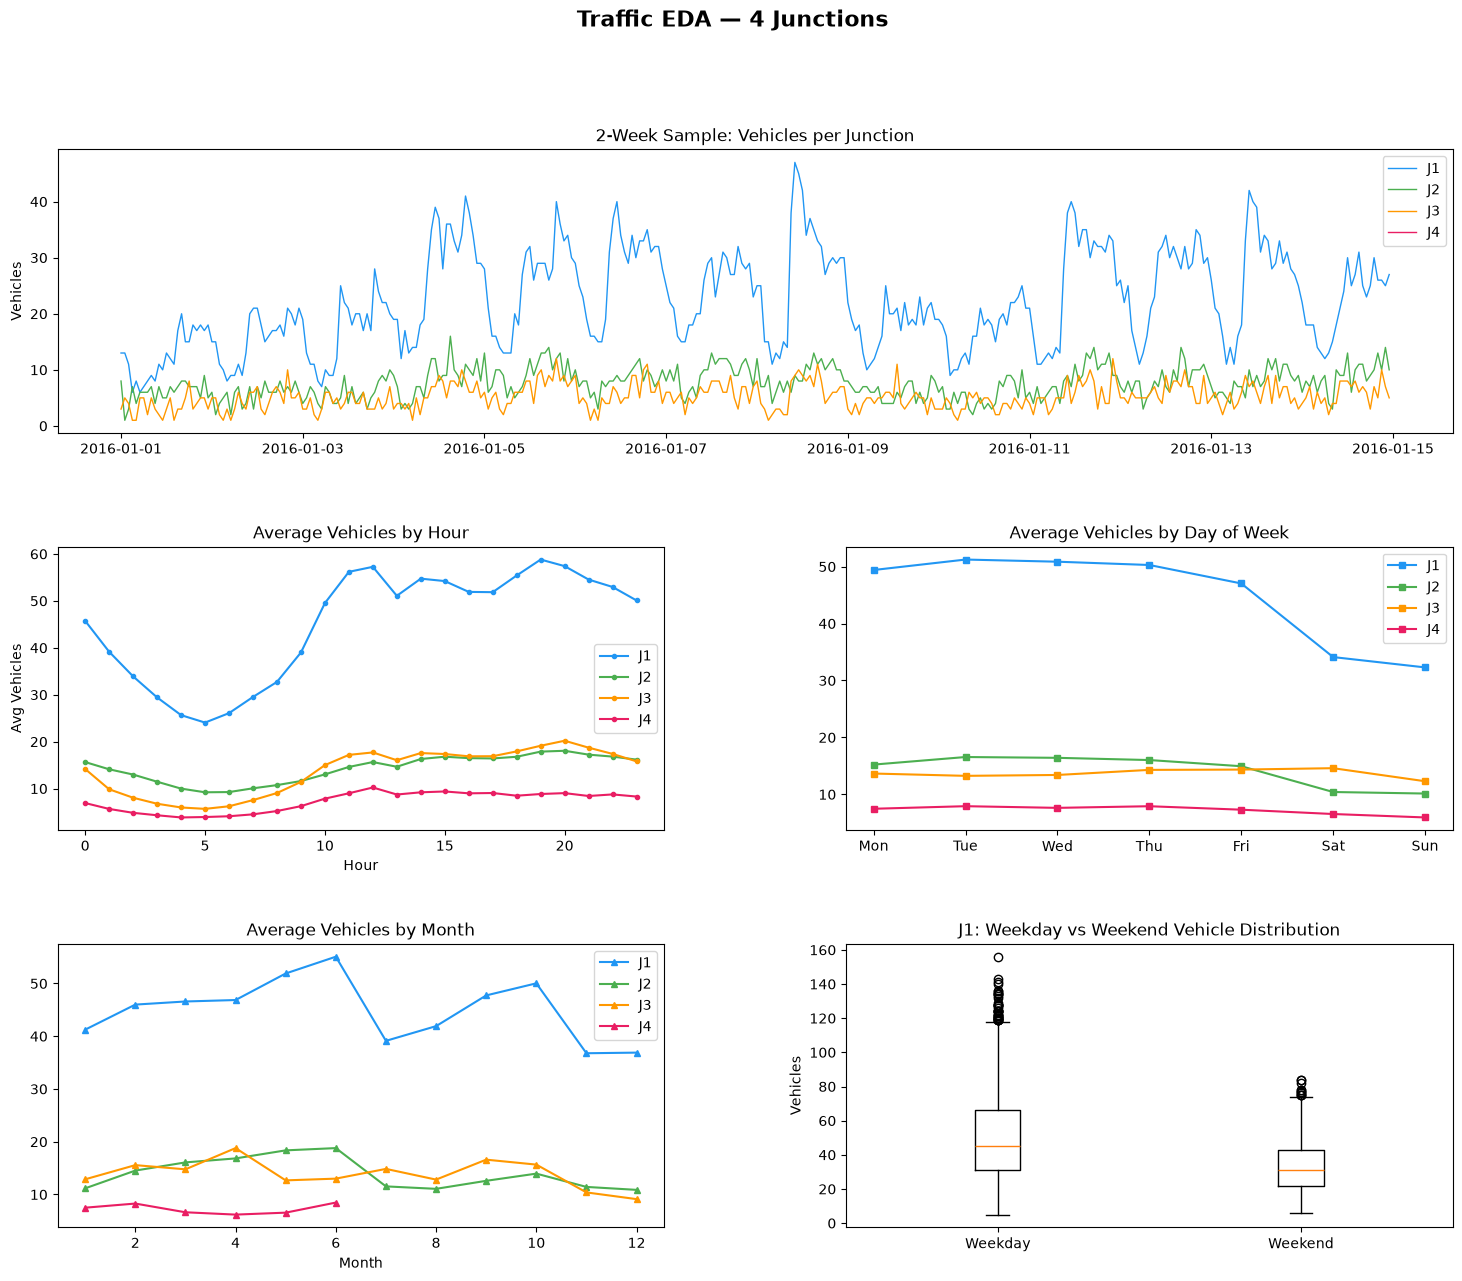

In [15]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Traffic EDA — 4 Junctions', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
 
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
junctions = [1, 2, 3, 4]
 
# Time series per junction (sample 2 weeks)
ax1 = fig.add_subplot(gs[0, :])
sample = train[(train['DateTime'] >= '2016-01-01') & (train['DateTime'] < '2016-01-15')]
for j, c in zip(junctions, colors):
    d = sample[sample['Junction'] == j]
    ax1.plot(d['DateTime'], d['Vehicles'], label=f'J{j}', color=c, linewidth=1)
ax1.set_title('2-Week Sample: Vehicles per Junction')
ax1.legend(); ax1.set_ylabel('Vehicles')
 
# Hourly pattern
ax2 = fig.add_subplot(gs[1, 0])
for j, c in zip(junctions, colors):
    d = train[train['Junction'] == j].groupby('hour')['Vehicles'].mean()
    ax2.plot(d.index, d.values, label=f'J{j}', color=c, marker='o', markersize=3)
ax2.set_title('Average Vehicles by Hour'); ax2.set_xlabel('Hour'); ax2.set_ylabel('Avg Vehicles')
ax2.legend()
 
# Day of week pattern
ax3 = fig.add_subplot(gs[1, 1])
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for j, c in zip(junctions, colors):
    d = train[train['Junction'] == j].groupby('dayofweek')['Vehicles'].mean()
    ax3.plot(d.index, d.values, label=f'J{j}', color=c, marker='s', markersize=4)
ax3.set_xticks(range(7)); ax3.set_xticklabels(days)
ax3.set_title('Average Vehicles by Day of Week'); ax3.legend()
 
# Monthly pattern
ax4 = fig.add_subplot(gs[2, 0])
for j, c in zip(junctions, colors):
    d = train[train['Junction'] == j].groupby('month')['Vehicles'].mean()
    ax4.plot(d.index, d.values, label=f'J{j}', color=c, marker='^', markersize=4)
ax4.set_title('Average Vehicles by Month'); ax4.set_xlabel('Month'); ax4.legend()
 
# Weekend vs Weekday boxplot (Junction 1)
ax5 = fig.add_subplot(gs[2, 1])
j1 = train[train['Junction'] == 1]
data_box = [j1[j1['is_weekend']==0]['Vehicles'].values,
            j1[j1['is_weekend']==1]['Vehicles'].values]
ax5.boxplot(data_box, tick_labels=['Weekday', 'Weekend'])
ax5.set_title('J1: Weekday vs Weekend Vehicle Distribution')
ax5.set_ylabel('Vehicles')
 
plt.savefig('traffic_eda.png', dpi=130, bbox_inches='tight')

OBSERVATIONS:
- Plot 1 — 2-week time series:
  - J1 dominates. 3–4× higher than J2/J3/J4
  - J4 absent (Jan 2016 sample — J4 data starts Jan 2017)
  - Clear daily cycle visible in J1. J2/J3 flatter but pattern still exists
  - Periodic dips = nights/weekends

- Plot 2 — Avg Vehicles by Hour:
  - J1 peaks ~10AM and again ~8PM (bimodal). Unusual — no classic AM rush spike, high even at midnight
  - J2/J3/J4 all show trough at 5AM, gradual rise through day, plateau mid-day to evening
  - All junctions: minimum traffic 4–6AM. Hard floor visible
  - J1 stays elevated even at hour 0 

- Plot 3 — Avg Vehicles by Day:
  - J1 massive drop Sat/Sun (~50→32). Strong weekend effect
  - J2 slight drop weekend. J3/J4 nearly flat — weekend barely affects them
  - Mon–Fri very consistent for all junctions. No mid-week anomaly

- Plot 4 — Avg Vehicles by Month:
  - J1 peaks Jun (month 6) then sharp drop Jul–Aug
  - J3 spikes month 4–6, drops sharply after — seasonal pattern worth noting
  - J2 relatively stable. J4 flat low (limited data, Jan–Jun only)
  - No junction shows December holiday spike

- Plot 5 — Weekday vs Weekend (J1):
  - Weekday median ~45, weekend median ~28. Big gap
  - Weekday has much higher variance + heavy outliers (up to 150+)
  - Weekend IQR narrower — traffic more predictable on weekends
  - Outliers on weekday side → special events, incidents worth engineering as feature

~ END ~